In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

In [2]:
!pip install lightgbm

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v6_lane_vehicle.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v6_lane_vehicle.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242965, 198)
(66060, 198)


In [5]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = (
    train_dataset["behavior"]
    .replace(behavior_map)
)

test_dataset["behavior"] = (
    test_dataset["behavior"]
    .replace(behavior_map)
)

print(train_dataset["behavior"].value_counts())

print()

print(test_dataset["behavior"].value_counts())

behavior
NORMAL        116203
AGGRESSIVE     63761
DROWSY         63001
Name: count, dtype: int64

behavior
DROWSY        36143
AGGRESSIVE    15257
NORMAL        14660
Name: count, dtype: int64


In [6]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_dataset.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X_train = train_dataset[feature_columns]
X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]
y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 194)
(66060, 194)


In [7]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [8]:
lgbm_model = LGBMClassifier(

    random_state=42,

    objective="multiclass",

    num_class=3

)

In [9]:
lgbm_model.fit(
    X_train,
    y_train
)

print("LightGBM trained successfully!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.677960 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47649
[LightGBM] [Info] Number of data points in the train set: 242965, number of used features: 190
[LightGBM] [Info] Start training from score -1.337776
[LightGBM] [Info] Start training from score -1.349767
[LightGBM] [Info] Start training from score -0.737579
LightGBM trained successfully!


In [10]:
lgbm_pred = lgbm_model.predict(
    X_test
)

lgbm_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 2, 2, 2])

In [11]:
accuracy = accuracy_score(
    y_test,
    lgbm_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6753


In [12]:
print(

    classification_report(

        y_test,

        lgbm_pred,

        target_names=label_encoder.classes_

    )

)

              precision    recall  f1-score   support

  AGGRESSIVE       0.86      0.85      0.85     15257
      DROWSY       0.89      0.53      0.67     36143
      NORMAL       0.42      0.84      0.56     14660

    accuracy                           0.68     66060
   macro avg       0.72      0.74      0.69     66060
weighted avg       0.78      0.68      0.69     66060



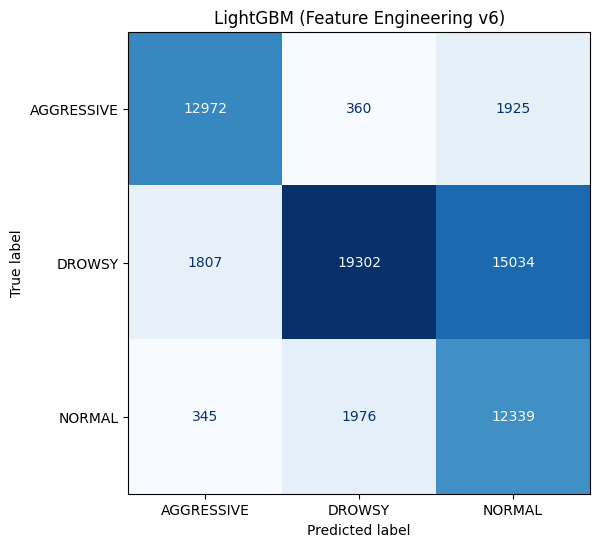

In [13]:
cm = confusion_matrix(
    y_test,
    lgbm_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("LightGBM (Feature Engineering v6)")

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": lgbm_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(30)

,Feature,Importance
76,yaw_max,497
78,yaw_rms,438
28,speed_max,437
75,yaw_min,425
63,pitch_min,232
27,speed_min,230
51,roll_min,214
150,relative_speed_rms,197
88,lane_offset_max,194
52,roll_max,178


# LightGBM Tuning v1

In [15]:
lgbm_model_v1 = LGBMClassifier(

    random_state=42,

    objective="multiclass",
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,

    num_leaves=63,
    max_depth=8,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_samples=20,

    reg_alpha=0.1,
    reg_lambda=1.0

)

In [16]:
lgbm_model_v1.fit(
    X_train,
    y_train
)

print("LightGBM Tuning v1 trained successfully!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.062991 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47649
[LightGBM] [Info] Number of data points in the train set: 242965, number of used features: 190
[LightGBM] [Info] Start training from score -1.337776
[LightGBM] [Info] Start training from score -1.349767
[LightGBM] [Info] Start training from score -0.737579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

In [17]:
lgbm_pred_v1 = lgbm_model_v1.predict(
    X_test
)

lgbm_pred_v1[:10]

array([0, 0, 2, 2, 2, 2, 2, 2, 2, 2])

In [18]:
accuracy = accuracy_score(
    y_test,
    lgbm_pred_v1
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6729


In [19]:
print(
    classification_report(
        y_test,
        lgbm_pred_v1,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.86      0.84      0.85     15257
      DROWSY       0.89      0.54      0.67     36143
      NORMAL       0.42      0.84      0.56     14660

    accuracy                           0.67     66060
   macro avg       0.72      0.74      0.69     66060
weighted avg       0.78      0.67      0.69     66060



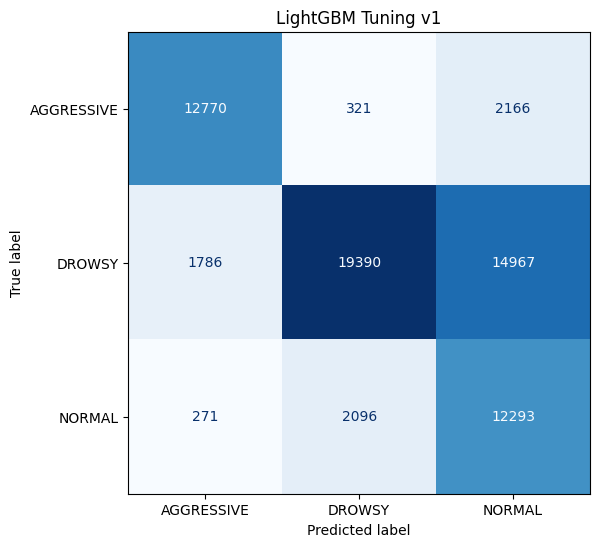

In [20]:
cm = confusion_matrix(
    y_test,
    lgbm_pred_v1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("LightGBM Tuning v1")

plt.show()